# Analysis 5: Race and Stop Type

This analysis examines whether race is associated with stop type. This matters because stop type may be a confounding variable in the relationship between race and person search.

If stop type is related to both race and person-search outcome, then the overall relationship between race and person search should be interpreted carefully.

The two variables used are:

- `race`
- `problem`

The main statistical method is a chi-square test of independence.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("MplsStops.csv")
df.head()

,Unnamed: 0,idNum,date,problem,MDC,citationIssued,personSearch,vehicleSearch,preRace,race,gender,lat,long,policePrecinct,neighborhood
0,6823,17-000003,2017-01-01 00:00:42,suspicious,MDC,NaN,NO,NO,Unknown,Unknown,Unknown,44.966617,-93.246458,1,Cedar Riverside
1,6824,17-000007,2017-01-01 00:03:07,suspicious,MDC,NaN,NO,NO,Unknown,Unknown,Male,44.980450,-93.271340,1,Downtown West
2,6825,17-000073,2017-01-01 00:23:15,traffic,MDC,NaN,NO,NO,Unknown,White,Female,44.948350,-93.275380,5,Whittier
3,6826,17-000092,2017-01-01 00:33:48,suspicious,MDC,NaN,NO,NO,Unknown,East African,Male,44.948360,-93.281350,5,Whittier
4,6827,17-000098,2017-01-01 00:37:58,traffic,MDC,NaN,NO,NO,Unknown,White,Female,44.979078,-93.262076,1,Downtown West


In [4]:
# Clean only the variables needed for this analysis
df["race"] = df["race"].astype("string").str.strip().str.lower()
df["problem"] = df["problem"].astype("string").str.strip().str.lower()

# Keep only rows with usable race and problem values
df = df.dropna(subset=["race", "problem"]).copy()

# Remove unknown race because it is not a specific racial group
df = df[df["race"] != "unknown"]

# Check values
print(df["race"].value_counts())
print()
print(df["problem"].value_counts())

race
black              15220
white              11703
east african        2188
latino              1858
native american     1516
other               1348
asian                647
Name: count, dtype: Int64

problem
traffic       22458
suspicious    12022
Name: count, dtype: Int64


In [5]:
race_problem_table = pd.crosstab(
    df["race"],
    df["problem"]
)

race_problem_table

problem,suspicious,traffic
race,,
asian,140,507
black,5458,9762
east african,643,1545
latino,531,1327
native american,1177,339
other,537,811
white,3536,8167


**PERCENT TABLE**

Within each race group, what percent of stops were traffic stops and what percent were suspicious-person/vehicle stops?

In [7]:
race_problem_percent = pd.crosstab(
    df["race"],
    df["problem"],
    normalize="index"
) * 100

race_problem_percent.round(2)

problem,suspicious,traffic
race,,
asian,21.64,78.36
black,35.86,64.14
east african,29.39,70.61
latino,28.58,71.42
native american,77.64,22.36
other,39.84,60.16
white,30.21,69.79


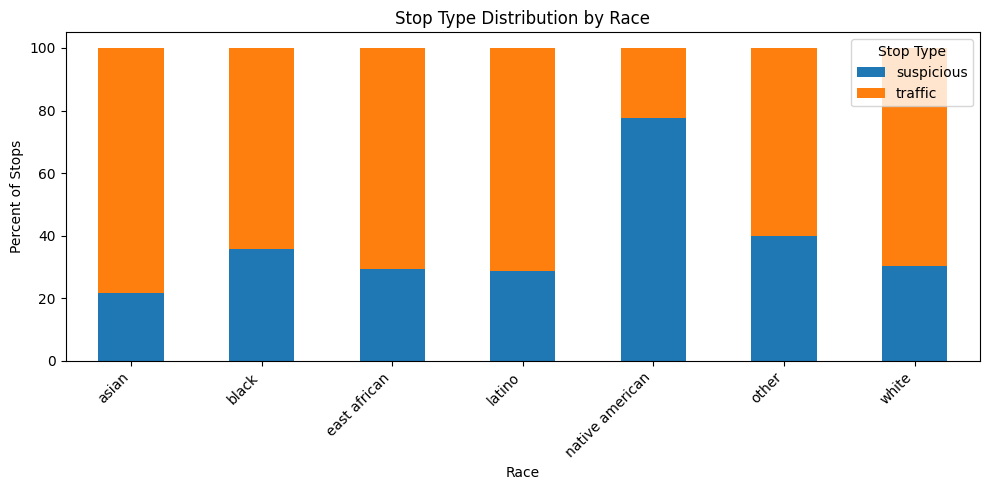

In [8]:
race_problem_percent.round(2).plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Stop Type Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Percent of Stops")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Stop Type")
plt.tight_layout()
plt.show()

In [9]:
from statsmodels.stats.contingency_tables import Table

sm_table_problem = Table(race_problem_table)

result_problem = sm_table_problem.test_nominal_association()

print("Chi-square statistic:", result_problem.statistic)
print("Degrees of freedom:", result_problem.df)
print("p-value:", result_problem.pvalue)

Chi-square statistic: 1465.1817832480526
Degrees of freedom: 6
p-value: 0.0


In [11]:
expected_problem_counts = pd.DataFrame(
    sm_table_problem.fittedvalues,
    index=race_problem_table.index,
    columns=race_problem_table.columns
)

display(expected_problem_counts.round(2))
print("Smallest expected count:", expected_problem_counts.min().min())

problem,suspicious,traffic
race,,
asian,225.59,421.41
black,5306.69,9913.31
east african,762.88,1425.12
latino,647.82,1210.18
native american,528.58,987.42
other,470.00,878.00
white,4080.44,7622.56


Smallest expected count: 225.5868329466357


## Chi-Square Test: Race and Stop Type

The hypotheses for this test were:

- \(H_0\): Race and stop type are independent.
- \(H_a\): Race and stop type are associated.

The chi-square test produced a test statistic of 1465.1818 with 6 degrees of freedom and a p-value that was less than 0.001.

Using a significance level of 0.05, we **reject** the null hypothesis.

In context, this means there is strong evidence that race and stop type are associated in the 2017 Minneapolis police stop data.

This matters because stop type may be a confounding variable. If stop type is associated with both race and person search, then the overall race/person-search relationship should be interpreted with stop type in mind.